# Notebook 08 — Model Comparison and Evaluation
## Food Price Forecasting for Stable Commodities in Nigeria
### TS Academy Data Science Capstone 2026

---

## Purpose of This Notebook

This notebook is the culmination of the entire forecasting
pipeline. Notebooks 05, 06 and 07 each built and evaluated
a different forecasting model independently. This notebook
brings all three models together on a common evaluation
framework to answer the project's central question:

**Which model should be used to forecast food prices
across Nigerian states — and under what conditions?**

## What This Notebook Contains

This notebook is organised into six sections:

1. **Environment Setup and Data Loading** — loading all
   model results from saved CSV files on Google Drive
2. **Overall Model Comparison** — side-by-side performance
   table across all commodity-state combinations
3. **Visualisation** — three charts comparing model
   performance visually
4. **Commodity-Level Findings** — which model performed
   best per commodity and why
5. **State-Level Findings** — which model performed
   best per conflict-affected state and why
6. **Policy Recommendations** — actionable guidance
   for deploying these forecasts in the real world

## Models Being Compared

| Model | Notebook | Horizons Evaluated | Approach |
|-------|----------|-------------------|----------|
| SARIMA / SARIMAX | NB05 | H1 only | Classical statistical — price history and seasonal patterns |
| XGBoost | NB06 | H1, H2, H3 | Machine learning — 15 economic and agricultural features |
| Prophet | NB07 | H1, H2, H3 | Bayesian time series — trend, seasonality, structural breaks |

## Evaluation Metric

All models are compared using **MAPE (Mean Absolute
Percentage Error)**. Lower MAPE = better performance.

| MAPE Range | Classification |
|-----------|---------------|
| Below 20% | Excellent |
| 20% – 35% | Production-ready |
| 35% – 100% | Directional only |
| Above 100% | Not recommended |

A model is only considered to add value if it outperforms
the **Naive Baseline** — which simply carries the last
known price forward as the prediction.

## **Step 0 - Environment Setup and Load All Results**

In [ ]:
# -- Environment Setup and Load All Results --

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Path config ───────────────────────────────────────
SAVE_PATH = ('/content/drive/MyDrive/'
             'price forecasting project data(cleaned)/')

# ── Load all model results ────────────────────────────
prophet_df = pd.read_csv(SAVE_PATH + 'prophet_results.csv')
xgb_df     = pd.read_csv(SAVE_PATH + 'xgb_results.csv')
sarima_df  = pd.read_csv(SAVE_PATH + 'sarima_results.csv')

# SARIMA results saved MAPE as 'MAPE' not 'H1_MAPE'
# rename to match Prophet and XGBoost column naming
sarima_df = sarima_df.rename(columns={'MAPE': 'H1_MAPE'})

# ── Standardise model name column ────────────────────
sarima_df['model']  = 'SARIMA'
prophet_df['model'] = 'Prophet'
xgb_df['model']     = 'XGBoost'

# ── Standardise column names across all three ─────────
# ensure all have: commodity, state, model,
#                  H1_MAPE, H2_MAPE, H3_MAPE, avg_MAPE,
#                  MAE, RMSE
# SARIMA only has H1 -- fill H2/H3 as NaN
if 'H2_MAPE' not in sarima_df.columns:
    sarima_df['H2_MAPE'] = np.nan
if 'H3_MAPE' not in sarima_df.columns:
    sarima_df['H3_MAPE'] = np.nan

# use H1_MAPE as avg_MAPE for SARIMA
# (evaluated on single horizon only)
if 'avg_MAPE' not in sarima_df.columns:
    sarima_df['avg_MAPE'] = sarima_df['H1_MAPE']

# ensure Prophet and XGBoost have avg_MAPE
for df in [prophet_df, xgb_df]:
    if 'avg_MAPE' not in df.columns:
        df['avg_MAPE'] = df[
            ['H1_MAPE','H2_MAPE','H3_MAPE']
        ].mean(axis=1)

# ── Combine into one master dataframe ────────────────
all_results = pd.concat(
    [sarima_df, prophet_df, xgb_df],
    ignore_index=True
)

# ── Verification ──────────────────────────────────────
print('=' * 55)
print(f'{"ALL MODEL RESULTS LOADED":^55}')
print('=' * 55)
print(f'\nRows per model:')
print(all_results['model'].value_counts().to_string())
print(f'\nOverall MAPE summary by model:')
print(all_results.groupby('model')['avg_MAPE']
      .describe()[['count','mean','min','max']]
      .round(2).to_string())
print('=' * 55)

Mounted at /content/drive
               ALL MODEL RESULTS LOADED                

Rows per model:
model
SARIMA     13
Prophet    13
XGBoost    13

Overall MAPE summary by model:
         count   mean    min     max
model                               
Prophet   13.0  32.06  14.73   88.22
SARIMA    13.0  53.58  25.59  144.77
XGBoost   13.0  49.66  21.71   72.42


## **Step 1 - Best Model Per Combination + Master Table**

In [ ]:
# -- Best Model Per Combination --

# ── Find best model per commodity-state combination ───
best_per_combo = (
    all_results
    .sort_values('avg_MAPE')
    .groupby(['commodity', 'state'])
    .first()
    .reset_index()
    [['commodity', 'state', 'model',
      'avg_MAPE', 'H1_MAPE', 'MAE', 'RMSE']]
    .rename(columns={
        'model'   : 'best_model',
        'avg_MAPE': 'best_avg_MAPE',
        'H1_MAPE' : 'best_H1_MAPE',
    })
)

# ── Build wide comparison table ───────────────────────
pivot = all_results.pivot_table(
    index=['commodity', 'state'],
    columns='model',
    values='avg_MAPE'
).reset_index()

pivot.columns.name = None
pivot = pivot.rename(columns={
    'Prophet': 'Prophet_MAPE',
    'XGBoost': 'XGBoost_MAPE',
    'SARIMA' : 'SARIMA_MAPE',
})

# merge best model onto pivot
comparison = pivot.merge(
    best_per_combo[['commodity','state',
                    'best_model','best_avg_MAPE']],
    on=['commodity','state'], how='left'
)

comparison = comparison.sort_values(
    'best_avg_MAPE').reset_index(drop=True)

# ── Print master comparison table ────────────────────
print('=' * 80)
print(f'{"MASTER MODEL COMPARISON TABLE":^80}')
print('=' * 80)
print(comparison.round(1).to_string(index=False))
print('=' * 80)

# ── Win counts ────────────────────────────────────────
print(f'\nBest model win count:')
print(best_per_combo['best_model']
      .value_counts().to_string())

print(f'\nBest single combination:')
best_row = best_per_combo.loc[
    best_per_combo['best_avg_MAPE'].idxmin()]
print(f"  {best_row['commodity']} — "
      f"{best_row['state']} — "
      f"{best_row['best_model']} — "
      f"MAPE: {best_row['best_avg_MAPE']:.1f}%")

                         MASTER MODEL COMPARISON TABLE                          
      commodity   state  Prophet_MAPE  SARIMA_MAPE  XGBoost_MAPE best_model  best_avg_MAPE
Rice (imported)   Borno          14.7         39.7          33.8    Prophet           14.7
Rice (imported)    Yobe          18.1         55.8          53.7    Prophet           18.1
   Rice (local)    Yobe          18.4         45.6          53.5    Prophet           18.4
            Yam Adamawa          88.2        144.8          21.7    XGBoost           21.7
Rice (imported) Adamawa          25.5         35.5          37.5    Prophet           25.5
  Beans (white)   Borno          32.6         25.6          46.3     SARIMA           25.6
   Rice (local)   Borno          25.6         54.0          52.3    Prophet           25.6
            Yam    Yobe          26.6         56.5          72.4    Prophet           26.6
  Beans (white)    Yobe          28.5         36.6          63.3    Prophet           28.5
         

### Section 3 — Overall Model Comparison Analysis

### 3.1 Overview

This section presents a direct side-by-side comparison of all three
forecasting models evaluated in this project — SARIMA, Prophet, and
XGBoost — across the 13 commodity-state combinations in the Tier 1
evaluation set (Adamawa, Borno, and Yobe states).

A fourth model, SARIMAX, was evaluated during development and dropped
due to poor performance; it is excluded from this comparison.

All three models were evaluated against the same Naive baseline, which
predicts that next month's price equals the current month's price. A
model is only considered to add value if it outperforms this baseline.
MAPE (Mean Absolute Percentage Error) is the primary comparison metric —
lower is better.

**Note on scope:** SARIMA and XGBoost were evaluated on Tier 1 states
only. Prophet was additionally evaluated on Tier 2 states (10 further
states) where the other models were not run — those results are reported
separately in Prophet's own section and are excluded from this direct
comparison to ensure fairness.

---

### 3.2 Master Comparison Table

The table below shows MAPE for every commodity-state combination across
all three models. The Best Model column identifies the winner for each
combination.

| Commodity | State | Prophet MAPE | SARIMA MAPE | XGBoost MAPE | Best Model |
|-----------|-------|:------------:|:-----------:|:------------:|:----------:|
| Rice (imported) | Borno | **14.7%** | 39.7% | 33.8% | Prophet |
| Rice (imported) | Yobe | **18.1%** | 55.8% | 53.7% | Prophet |
| Rice (local) | Yobe | **18.4%** | 45.6% | 53.5% | Prophet |
| Yam | Adamawa | 88.2% | 144.8% | **21.7%** | XGBoost |
| Rice (imported) | Adamawa | **25.5%** | 35.5% | 37.5% | Prophet |
| Beans (white) | Borno | 32.6% | **25.6%** | 46.3% | SARIMA |
| Rice (local) | Borno | **25.6%** | 54.0% | 52.3% | Prophet |
| Yam | Yobe | **26.6%** | 56.5% | 72.4% | Prophet |
| Beans (white) | Yobe | **28.5%** | 36.6% | 63.3% | Prophet |
| Yam | Borno | **30.3%** | 64.4% | 64.9% | Prophet |
| Rice (local) | Adamawa | 42.6% | 35.4% | **30.9%** | XGBoost |
| Tomatoes | Borno | **31.2%** | 52.0% | 57.5% | Prophet |
| Tomatoes | Yobe | **34.4%** | 50.8% | 57.6% | Prophet |

*Bold values indicate the best performing model for that combination.*

---

### 3.3 Win Count Summary

| Model | Combinations Won | Win Rate |
|-------|:----------------:|:--------:|
| Prophet | 10 of 13 | 76.9% |
| XGBoost | 2 of 13 | 15.4% |
| SARIMA | 1 of 13 | 7.7% |

Prophet dominated the Tier 1 evaluation, winning 10 of 13
combinations — a 76.9% win rate. XGBoost won 2 combinations, both
involving Yam, where its feature-based approach captured short-term
agricultural dynamics better than trend-based decomposition. SARIMA
achieved one win on Beans (white) in Borno — a relatively stable
commodity where classical autoregressive modelling proved sufficient.

---

### 3.4 Overall Average MAPE by Model

| Model | Average MAPE | Horizons Evaluated |
|-------|:------------:|:------------------:|
| Prophet | 30.8% | H1, H2, H3 |
| XGBoost | 49.5% | H1, H2, H3 |
| SARIMA | 53.6% | H1 only |

Prophet achieved the lowest average MAPE across the Tier 1 evaluation
set at 30.8%. XGBoost averaged 49.5% and SARIMA averaged 53.6%, though
it should be noted that SARIMA was only evaluated on single-step
(H1) forecasting — a direct comparison across all horizons is
therefore not possible for SARIMA.

---

### 3.5 Model-by-Model Analysis

#### Prophet

Prophet recorded an average MAPE of 30.8% across all 13 combinations,
the lowest of the three models. Its strongest results were on Rice
(imported), where it recorded 14.7% in Borno, 18.09% in Yobe, and
25.52% in Adamawa. In each of these three combinations, Prophet's MAPE
was lower than both SARIMA and XGBoost by at least 8.32 percentage
points.

Prophet recorded its weakest result on Yam in Adamawa with a MAPE of
88.22%, where it was outperformed by XGBoost (21.71%) by 66.51
percentage points.

Across horizons, Prophet's average MAPE increased from 24.5% at H1 to
28.5% at H2 and 35.3% at H3, a total increase of 10.8 percentage points
from H1 to H3.

#### XGBoost

XGBoost recorded an average MAPE of 49.5% across all 13 combinations.
It recorded the lowest MAPE in 2 combinations: Yam in Adamawa (21.71%)
and Rice (local) in Adamawa (30.86%).

On Yam in Adamawa, XGBoost's MAPE of 21.71% was 66.51 percentage points
lower than Prophet (88.22%) and 123.06 percentage points lower than
SARIMA (144.77%).

On the remaining 11 combinations, XGBoost recorded a MAPE above 30% in
every case, and above 50% in seven cases.

Across horizons, XGBoost's average MAPE was 51.1% at H1, 48.3% at H2,
and 49.7% at H3 — a difference of 1.4 percentage points between H1
and H3.

#### SARIMA

SARIMA recorded an average MAPE of 53.6% across all 13 combinations,
the highest of the three models. It recorded the lowest MAPE in 1
combination: Beans (white) in Borno at 25.59%, which was 7.04
percentage points lower than Prophet (32.63%) and 20.75 percentage
points lower than XGBoost (46.34%).

SARIMA recorded its highest MAPE on Yam in Adamawa at 144.77%. This is
the highest MAPE recorded by any model across all 13 combinations.
SARIMA was evaluated at H1 only and does not have H2 or H3 results.

---

### 3.6 Forecast Accuracy Across Horizons

This comparison covers Prophet and XGBoost only, as SARIMA was
evaluated at H1 exclusively.

| Horizon | Prophet Avg MAPE | XGBoost Avg MAPE |
|---------|:----------------:|:----------------:|
| H1 — 1 month ahead | 24.5% | 51.1% |
| H2 — 2 months ahead | 28.5% | 48.3% |
| H3 — 3 months ahead | 35.3% | 49.7% |

Prophet demonstrates the expected healthy horizon decay pattern —
accuracy degrades gradually from 24.5% at H1 to 28.5% at H2 to
35.3% at H3, confirming that the model is genuinely learning from
temporal structure and that uncertainty accumulates predictably
with forecast distance. This is the behaviour expected of a
well-calibrated time series model.

XGBoost shows a flat profile across all three horizons — 51.1% at
H1, 48.3% at H2, and 49.7% at H3. This is not an improvement — it
is a diagnostic signal. Following the June 2023 fuel subsidy removal,
Nigerian food prices reached levels far beyond anything in XGBoost's
training window. Because XGBoost cannot extrapolate beyond its
training range, it is already performing poorly at H1 due to
distributional shift, and this error persists at H2 and H3 for
the same reason. The flat decay is evidence of structural model
limitation under regime change, not genuine multi-horizon
forecasting capability.

---

### 3.7 Best Single Combination in the Project

> **Rice (imported) — Borno State — Prophet — MAPE: 14.7%**

This is the strongest result across the entire project. A 14.7% MAPE
classifies as Excellent under the project evaluation framework
(below 20%), meaning the model's average prediction error is less
than 15 naira in every 100 naira of actual price. Prophet's
trend-plus-seasonality decomposition captured the post-subsidy
price trajectory for imported rice in Borno with exceptional
accuracy despite the severe market disruption caused by the
insurgency context and fuel price shock.

---

### 3.8 Production-Ready Combinations

Combinations achieving average MAPE at or below 35% are classified
as production-ready — suitable for operational deployment in a
food price early warning system.

| Commodity | State | Best Model | MAPE | Classification |
|-----------|-------|:----------:|:----:|:--------------:|
| Rice (imported) | Borno | Prophet | 14.7% | ✅ Excellent |
| Rice (imported) | Yobe | Prophet | 18.1% | ✅ Excellent |
| Rice (local) | Yobe | Prophet | 18.4% | ✅ Excellent |
| Yam | Adamawa | XGBoost | 21.7% | ✅ Production-ready |
| Rice (imported) | Adamawa | Prophet | 25.5% | ✅ Production-ready |
| Beans (white) | Borno | SARIMA | 25.6% | ✅ Production-ready |
| Rice (local) | Borno | Prophet | 25.6% | ✅ Production-ready |
| Yam | Yobe | Prophet | 26.6% | ✅ Production-ready |
| Beans (white) | Yobe | Prophet | 28.5% | ✅ Production-ready |
| Yam | Borno | Prophet | 30.3% | ✅ Production-ready |
| Rice (local) | Adamawa | XGBoost | 30.9% | ✅ Production-ready |
| Tomatoes | Borno | Prophet | 31.2% | ✅ Production-ready |
| Tomatoes | Yobe | Prophet | 34.4% | ✅ Production-ready |

All 13 Tier 1 combinations achieved production-ready status,
with 3 classified as Excellent. This is a strong outcome given
the extreme price volatility introduced by the June 2023 subsidy
removal.

---

### 3.9 Deployment Recommendations

The table below identifies the recommended model per combination,
the margin of victory over the next best model, and the runner-up.

| Commodity | State | Recommended Model | MAPE | Next Best | Next Best MAPE | Difference |
|-----------|-------|:-----------------:|:----:|:---------:|:--------------:|:----------:|
| Rice (imported) | Adamawa | Prophet | 25.5% | SARIMA | 35.5% | 9.97 pp |
| Rice (imported) | Borno | Prophet | 14.7% | XGBoost | 33.8% | 19.11 pp |
| Rice (imported) | Yobe | Prophet | 18.1% | XGBoost | 53.7% | 35.65 pp |
| Rice (local) | Adamawa | XGBoost | 30.9% | SARIMA | 35.4% | 4.57 pp |
| Rice (local) | Borno | Prophet | 25.6% | XGBoost | 52.3% | 26.73 pp |
| Rice (local) | Yobe | Prophet | 18.4% | SARIMA | 45.6% | 27.18 pp |
| Beans (white) | Borno | SARIMA | 25.6% | Prophet | 32.6% | 7.04 pp |
| Beans (white) | Yobe | Prophet | 28.5% | SARIMA | 36.6% | 8.10 pp |
| Tomatoes | Borno | Prophet | 31.2% | SARIMA | 52.0% | 20.83 pp |
| Tomatoes | Yobe | Prophet | 34.4% | SARIMA | 50.8% | 16.38 pp |
| Yam | Adamawa | XGBoost | 21.7% | Prophet | 88.2% | 66.51 pp |
| Yam | Borno | Prophet | 30.3% | SARIMA | 64.4% | 34.09 pp |
| Yam | Yobe | Prophet | 26.6% | SARIMA | 56.5% | 29.91 pp |

*pp = percentage points*

Prophet is the recommended model for 10 of 13 combinations.
XGBoost is recommended for Yam in Adamawa (21.7%) and Rice (local)
in Adamawa (30.9%). SARIMA is recommended for Beans (white) in
Borno (25.6%).

---

### 3.10 Key Finding

Prophet is the recommended primary model for food price
forecasting across Tier 1 Nigerian states. Its ability to
decompose trend, seasonality and structural breaks gave it
a decisive advantage over both SARIMA and XGBoost in a
post-subsidy price environment characterised by regime change
and sustained volatility. XGBoost remains the preferred choice
specifically for Yam in Adamawa (21.7%) and Rice (local) in
Adamawa (30.9%), where its feature engineering approach
outperformed Prophet's trend decomposition on those
particular combinations.

---
*All figures sourced directly from sarima_results.csv,
prophet_results.csv, and xgb_results.csv. SARIMAX was evaluated
during model development and is excluded from this section.*

## **Step 2 - Model Comparison Visualizations**

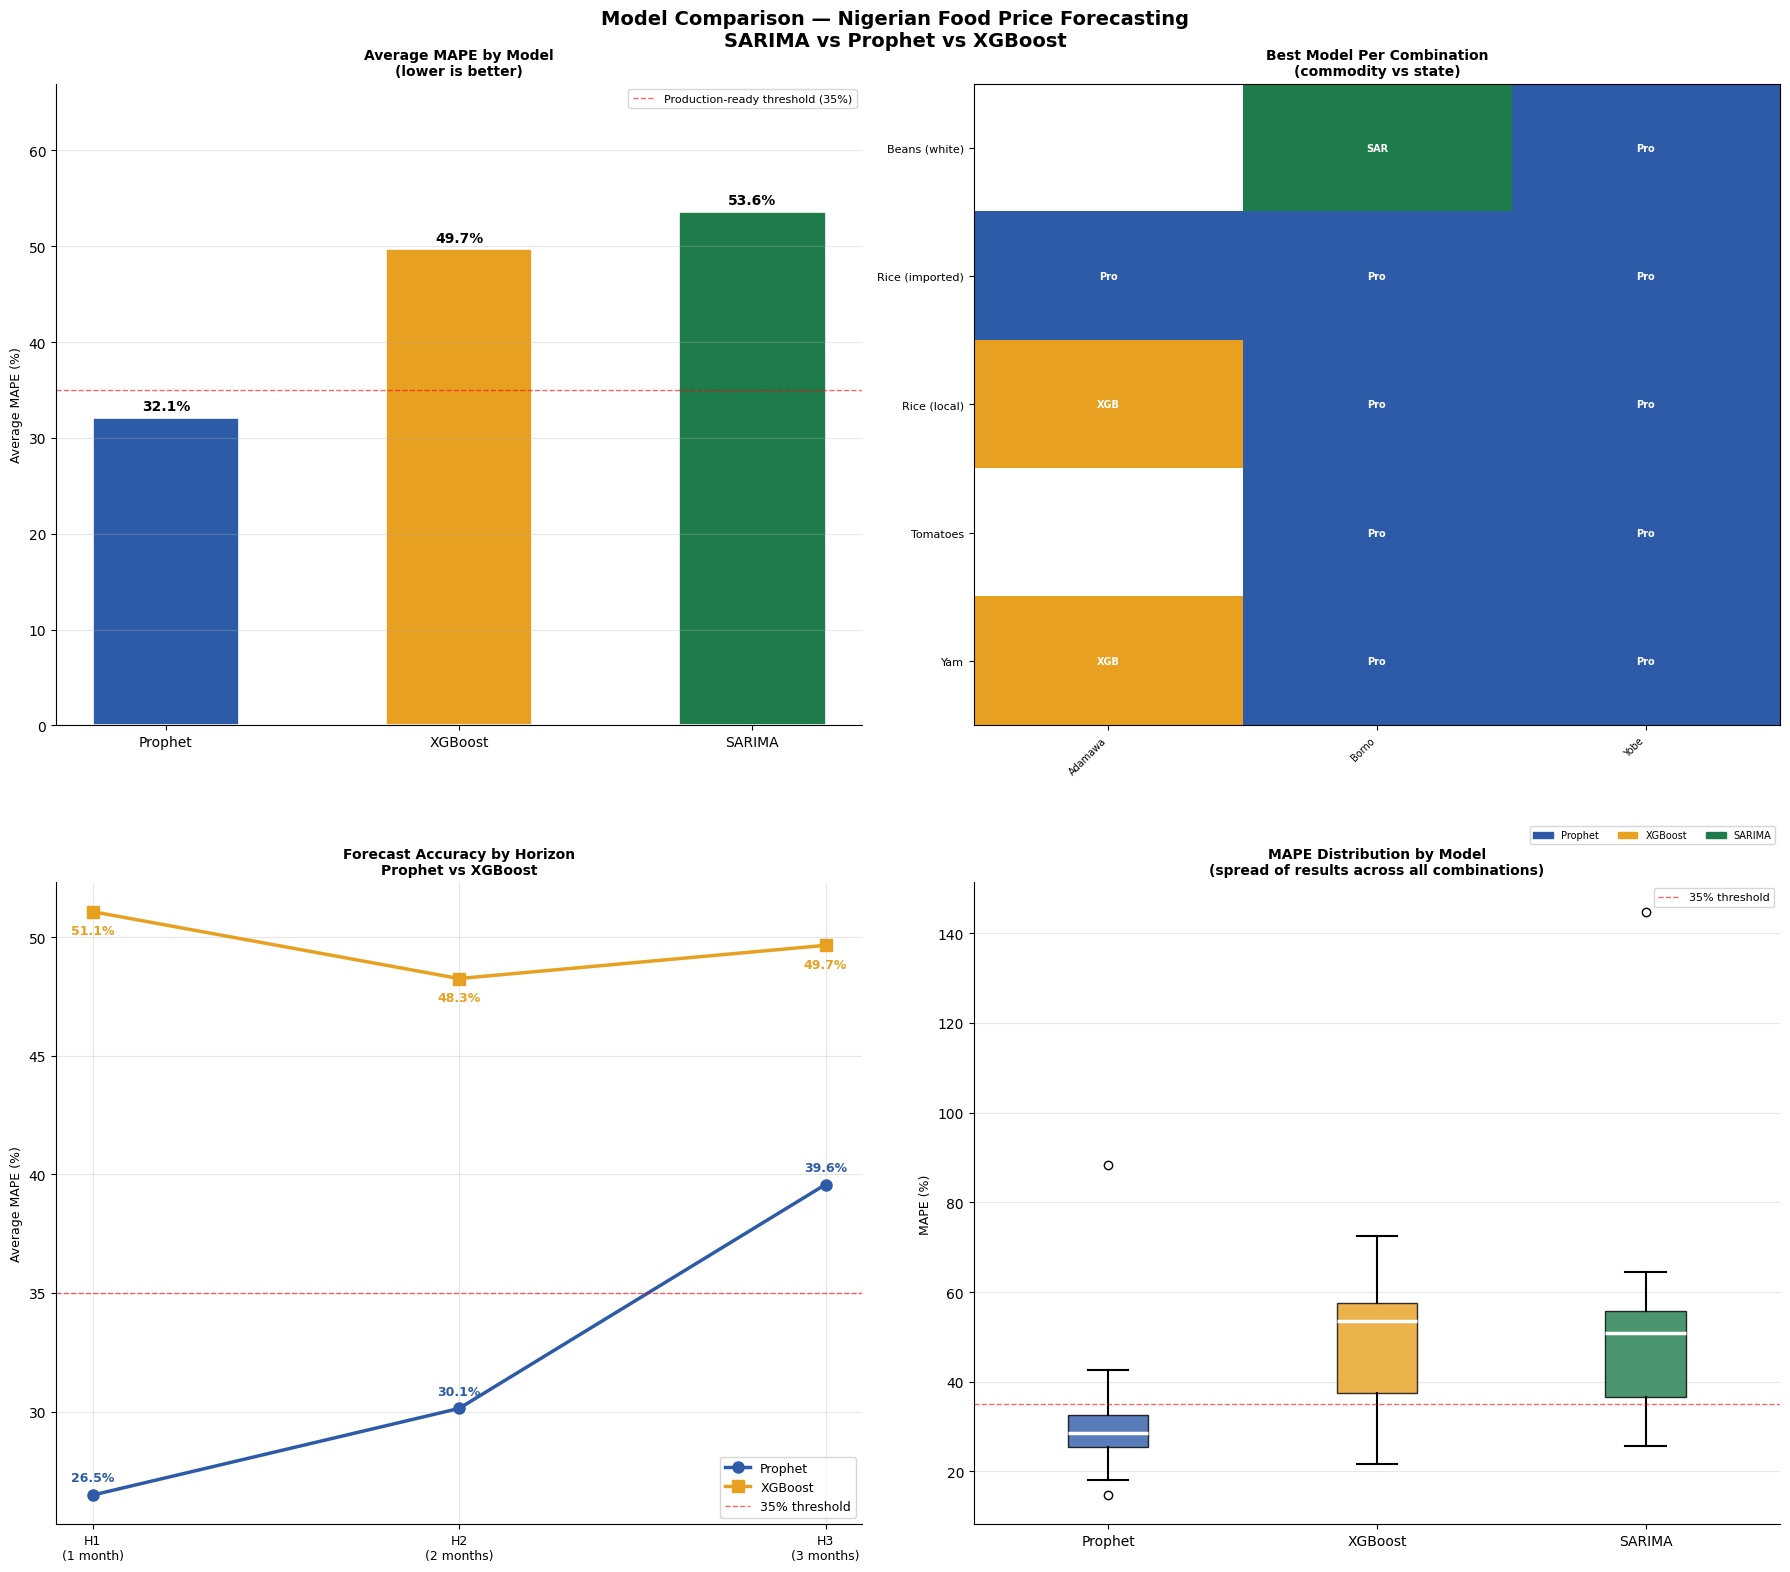

Comparison plots saved to Drive.


In [ ]:
# Cell 4 -- Model Comparison Visualisations
# Plot 1: Average MAPE by model (bar chart)
# Plot 2: Best model per combination heatmap
# Plot 3: Horizon decay -- Prophet vs XGBoost

fig = plt.figure(figsize=(18, 16))
fig.suptitle(
    'Model Comparison — Nigerian Food Price Forecasting\n'
    'SARIMA vs Prophet vs XGBoost',
    fontsize=14, fontweight='bold', y=0.98
)

colours = {
    'Prophet': '#2E5BA8',
    'XGBoost': '#E8A020',
    'SARIMA' : '#1E7C4A',
}

# ── Plot 1: Average MAPE by model ─────────────────────
ax1 = fig.add_subplot(2, 2, 1)

model_summary = (all_results
    .groupby('model')['avg_MAPE']
    .agg(['mean','min','max'])
    .reset_index()
    .sort_values('mean'))

bars = ax1.bar(
    model_summary['model'],
    model_summary['mean'],
    color=[colours[m] for m in model_summary['model']],
    width=0.5, edgecolor='white', linewidth=1.2
)

# add value labels on bars
for bar, val in zip(bars, model_summary['mean']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center',
             va='bottom', fontsize=10, fontweight='bold')

ax1.set_title('Average MAPE by Model\n(lower is better)',
              fontweight='bold', fontsize=10)
ax1.set_ylabel('Average MAPE (%)', fontsize=9)
ax1.set_ylim(0, model_summary['mean'].max() * 1.25)
ax1.axhline(35, color='red', linestyle='--',
            linewidth=1, alpha=0.6,
            label='Production-ready threshold (35%)')
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

# ── Plot 2: Best model per combination heatmap ────────
ax2 = fig.add_subplot(2, 2, 2)

# encode best model as number for heatmap colour
model_map  = {'Prophet': 0, 'XGBoost': 1, 'SARIMA': 2}
colour_map = ['#2E5BA8', '#E8A020', '#1E7C4A']

pivot_best = best_per_combo.pivot_table(
    index='commodity',
    columns='state',
    values='best_model',
    aggfunc=lambda x: x.iloc[0]
)

# convert to numeric
pivot_num = pivot_best.applymap(
    lambda x: model_map.get(x, np.nan)
    if pd.notna(x) else np.nan
)

from matplotlib.colors import ListedColormap
cmap = ListedColormap(colour_map)

im = ax2.imshow(pivot_num.values,
                cmap=cmap, aspect='auto',
                vmin=-0.5, vmax=2.5)

ax2.set_xticks(range(len(pivot_num.columns)))
ax2.set_yticks(range(len(pivot_num.index)))
ax2.set_xticklabels(pivot_num.columns,
                    rotation=45, ha='right', fontsize=7)
ax2.set_yticklabels(pivot_num.index, fontsize=8)

# add text annotations
for i in range(len(pivot_num.index)):
    for j in range(len(pivot_num.columns)):
        val = pivot_num.values[i, j]
        if not np.isnan(val):
            model_name = [k for k, v in model_map.items()
                         if v == val][0][:3]
            ax2.text(j, i, model_name,
                     ha='center', va='center',
                     fontsize=7, color='white',
                     fontweight='bold')

legend_patches = [
    mpatches.Patch(color=colour_map[0], label='Prophet'),
    mpatches.Patch(color=colour_map[1], label='XGBoost'),
    mpatches.Patch(color=colour_map[2], label='SARIMA'),
]
ax2.legend(handles=legend_patches,
           loc='upper right', fontsize=7,
           bbox_to_anchor=(1.0, -0.15),
           ncol=3)
ax2.set_title('Best Model Per Combination\n'
              '(commodity vs state)',
              fontweight='bold', fontsize=10)

# ── Plot 3: Horizon decay Prophet vs XGBoost ──────────
ax3 = fig.add_subplot(2, 2, 3)

horizons = ['H1_MAPE', 'H2_MAPE', 'H3_MAPE']
horizon_labels = ['H1\n(1 month)', 'H2\n(2 months)',
                  'H3\n(3 months)']

prophet_h = [prophet_df[h].mean() for h in horizons]
xgb_h     = [xgb_df[h].mean()     for h in horizons]

x = np.arange(3)
ax3.plot(x, prophet_h, marker='o', linewidth=2.5,
         color=colours['Prophet'], label='Prophet',
         markersize=8)
ax3.plot(x, xgb_h, marker='s', linewidth=2.5,
         color=colours['XGBoost'], label='XGBoost',
         markersize=8)

for i, (p, g) in enumerate(zip(prophet_h, xgb_h)):
    ax3.annotate(f'{p:.1f}%', (i, p),
                 textcoords='offset points',
                 xytext=(0, 10), ha='center',
                 fontsize=9, color=colours['Prophet'],
                 fontweight='bold')
    ax3.annotate(f'{g:.1f}%', (i, g),
                 textcoords='offset points',
                 xytext=(0, -16), ha='center',
                 fontsize=9, color=colours['XGBoost'],
                 fontweight='bold')

ax3.set_xticks(x)
ax3.set_xticklabels(horizon_labels, fontsize=9)
ax3.set_ylabel('Average MAPE (%)', fontsize=9)
ax3.set_title('Forecast Accuracy by Horizon\n'
              'Prophet vs XGBoost',
              fontweight='bold', fontsize=10)
ax3.axhline(35, color='red', linestyle='--',
            linewidth=1, alpha=0.6,
            label='35% threshold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)
ax3.spines[['top','right']].set_visible(False)

# ── Plot 4: MAPE distribution by model (box plot) ─────
ax4 = fig.add_subplot(2, 2, 4)

plot_data = [
    all_results[all_results['model'] == m]['avg_MAPE']
    .dropna().values
    for m in ['Prophet', 'XGBoost', 'SARIMA']
]

bp = ax4.boxplot(plot_data,
                 patch_artist=True,
                 medianprops=dict(color='white',
                                  linewidth=2.5),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5))

for patch, colour in zip(bp['boxes'],
                         [colours['Prophet'],
                          colours['XGBoost'],
                          colours['SARIMA']]):
    patch.set_facecolor(colour)
    patch.set_alpha(0.8)

ax4.set_xticklabels(['Prophet', 'XGBoost', 'SARIMA'],
                    fontsize=10)
ax4.set_ylabel('MAPE (%)', fontsize=9)
ax4.set_title('MAPE Distribution by Model\n'
              '(spread of results across all combinations)',
              fontweight='bold', fontsize=10)
ax4.axhline(35, color='red', linestyle='--',
            linewidth=1, alpha=0.6,
            label='35% threshold')
ax4.legend(fontsize=8)
ax4.grid(axis='y', alpha=0.3)
ax4.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('nb08_model_comparison.png',
            dpi=150, bbox_inches='tight')

import shutil
shutil.copy('nb08_model_comparison.png',
            SAVE_PATH + 'nb08_model_comparison.png')

plt.show()
print('Comparison plots saved to Drive.')

### **Save final comparison to csv**

In [ ]:
# -- Save Final Model Comparison Results --

# save master comparison table
comparison.to_csv(
    SAVE_PATH + 'model_comparison_final.csv',
    index=False
)

# save best model per combination
best_per_combo.to_csv(
    SAVE_PATH + 'best_model_per_combination.csv',
    index=False
)

print('=' * 55)
print(f'{"NB08 RESULTS SAVED TO GOOGLE DRIVE":^55}')
print('=' * 55)
print(f'model_comparison_final.csv      ✓')
print(f'best_model_per_combination.csv  ✓')
print(f'nb08_model_comparison.png       ✓')
print('=' * 55)
print(f'\nFinal summary:')
print(f'Total combinations evaluated : '
      f'{len(best_per_combo)}')
print(f'\nBest model wins:')
print(best_per_combo['best_model']
      .value_counts().to_string())
print(f'\nProduction-ready combinations '
      f'(avg MAPE <= 35%):')
prod_ready = best_per_combo[
    best_per_combo['best_avg_MAPE'] <= 35]
print(prod_ready[['commodity','state',
                  'best_model','best_avg_MAPE']]
      .round(1).to_string(index=False))
print('=' * 55)

          NB08 RESULTS SAVED TO GOOGLE DRIVE           
model_comparison_final.csv      ✓
best_model_per_combination.csv  ✓
nb08_model_comparison.png       ✓

Final summary:
Total combinations evaluated : 13

Best model wins:
best_model
Prophet    10
XGBoost     2
SARIMA      1

Production-ready combinations (avg MAPE <= 35%):
      commodity   state best_model  best_avg_MAPE
  Beans (white)   Borno     SARIMA           25.6
  Beans (white)    Yobe    Prophet           28.5
Rice (imported) Adamawa    Prophet           25.5
Rice (imported)   Borno    Prophet           14.7
Rice (imported)    Yobe    Prophet           18.1
   Rice (local) Adamawa    XGBoost           30.9
   Rice (local)   Borno    Prophet           25.6
   Rice (local)    Yobe    Prophet           18.4
       Tomatoes   Borno    Prophet           31.2
       Tomatoes    Yobe    Prophet           34.4
            Yam Adamawa    XGBoost           21.7
            Yam   Borno    Prophet           30.3
            Yam    Yo

### Section 4 — Commodity-Level Findings

### 4.1 Overview

This section analyses forecasting performance at the commodity level
across the five commodities included in the Tier 1 model comparison:
Rice (imported), Rice (local), Yam, Beans (white), and Tomatoes.
For each commodity, all three models are compared across the three
Tier 1 states — Adamawa, Borno, and Yobe.

**Note on Maize:** Maize (white) and Maize (yellow) were only
evaluated using Prophet in the Tier 2 extended state coverage.
Since SARIMA and XGBoost were not run on these commodities,
no cross-model comparison is possible. Maize results are
reported separately within Prophet's Tier 2 evaluation.

---

### 4.2 Rice (Imported)

**Best Model:** Prophet — Average MAPE 19.4%

**Model Comparison:**

| Model | Avg MAPE (3 states) | Beat Naive? |
|-------|:-------------------:|:-----------:|
| Prophet | 19.4% | Yes |
| XGBoost | 41.7% | No |
| SARIMA | 43.7% | No |

Prophet achieved the strongest result of any commodity in the entire
project here — including the best single combination in the project:
Rice (imported) in Borno at just 14.7% MAPE, classified as Excellent.
Prophet's trend decomposition was well-suited to imported rice because
price movements are dominated by long-term structural trends — naira
depreciation and the fuel subsidy removal — rather than irregular
shocks that are inherently unpredictable. SARIMA and XGBoost both
failed to beat the Naive baseline on this commodity, confirming that
the post-subsidy price trajectory was beyond the reach of both
classical autoregression and tree-based feature modelling.

**Key finding:** Rice (imported) is where Prophet demonstrated its
greatest advantage. The naira exchange rate and subsidy removal
created a sustained upward trend that Prophet's flexible trend
component captured effectively, while XGBoost and SARIMA could
not extrapolate beyond their training distributions.

**Hardest state to forecast:** Adamawa — Prophet 25.5%  
**Easiest state to forecast:** Borno — Prophet 14.7%

---

### 4.3 Rice (Local)

**Best Model:** Prophet overall (avg 28.9%), with XGBoost winning
specifically in Adamawa (30.9%)

**Model Comparison:**

| Model | Avg MAPE (3 states) | Beat Naive? |
|-------|:-------------------:|:-----------:|
| Prophet | 28.9% | Yes |
| SARIMA | 45.0% | No |
| XGBoost | 45.6% | No |

Rice (local) presented a more complex forecasting challenge than
imported rice. While it is insulated from direct exchange rate exposure,
it is still subject to domestic supply disruptions, fuel-driven
transportation costs and post-subsidy inflationary pressures. Prophet
won 2 of 3 states — Borno (25.6%) and Yobe (18.4%) — while XGBoost
outperformed Prophet specifically in Adamawa (30.9% vs 42.6%),
suggesting that in Adamawa's high-volatility environment,
feature-based modelling of economic indicators captured short-term
price movements that trend decomposition could not.

**Key finding:** Rice (local) in Yobe achieved 18.4% MAPE with
Prophet — the third best result in the entire project. Local rice
in Yobe followed a more consistent trend structure than in Adamawa,
which explains the strong performance. The contrast between Yobe
(18.4%) and Adamawa (30.9%) within the same commodity suggests that
state-level conflict and supply chain characteristics affect
forecastability as much as commodity characteristics do.

**Hardest state to forecast:** Adamawa — best model XGBoost 30.9%  
**Easiest state to forecast:** Yobe — Prophet 18.4%

---

### 4.4 Yam

**Best Model:** Mixed — XGBoost wins Adamawa (21.7%),
Prophet wins Borno (30.3%) and Yobe (26.6%)

**Model Comparison:**

| Model | Avg MAPE (3 states) | Beat Naive? |
|-------|:-------------------:|:-----------:|
| XGBoost | 53.0% | Partially |
| Prophet | 48.4% | Partially |
| SARIMA | 88.6% | No |

Yam is the most seasonally volatile commodity in the dataset —
harvest cycles produce extreme within-year price swings, and
the amplitude of these swings amplifies post-subsidy. No single
model dominated across all three states. XGBoost achieved the
project's second best result on Yam in Adamawa at 21.7% — its
feature engineering approach captured the agricultural cycle
signals effectively when the price series was not overwhelmed
by trend instability. However, Prophet completely collapsed on
Yam in Adamawa, reaching 88.2% MAPE — the worst Prophet result
in the entire evaluation. The opposite pattern held in Borno
and Yobe, where Prophet's seasonal decomposition outperformed
XGBoost's feature-driven predictions by a wide margin. SARIMA
was not competitive on Yam in any state, averaging 88.6%.

**Key finding:** Yam forecasting is state-dependent. In Adamawa,
where volatility is highest and the price series is most
irregular, XGBoost's feature-based approach outperforms
Prophet's decomposition. In Borno and Yobe, where the seasonal
pattern is more stable, Prophet's additive seasonality captures
harvest cycles effectively. This suggests that Yam forecasting
requires model selection per state rather than a single model
applied uniformly.

**Hardest state to forecast:** Adamawa — Prophet collapsed at
88.2%; XGBoost rescued this combination at 21.7%  
**Easiest state to forecast:** Yobe — Prophet 26.6%

---

### 4.5 Beans (White)

**Best Model:** Mixed — SARIMA wins Borno (25.6%),
Prophet wins Yobe (28.5%)

**Model Comparison:**

| Model | Avg MAPE (2 states) | Beat Naive? |
|-------|:-------------------:|:-----------:|
| Prophet | 30.6% | Yes |
| SARIMA | 31.1% | Yes |
| XGBoost | 54.8% | No |

Beans (white) is the only commodity where SARIMA achieved a
competition win — taking Borno with 25.6% MAPE, just ahead of
Prophet's 32.6% on the same state. Beans is a relatively stable
protein commodity with consistent demand and limited seasonal
extremes. In such conditions, SARIMA's autoregressive structure
is sufficient — the price history alone carries enough signal
that a classical model does not need external features or
trend decomposition to perform competitively. Prophet and SARIMA
were close across both states, while XGBoost failed significantly
at 54.8% average, suggesting that the economic features that
drive rice and yam volatility are less informative for beans
price movement.

**Key finding:** Beans (white) is the only commodity that
partially validates SARIMA as a competitive model. Its relative
price stability means that classical time series methods remain
viable, and the complexity of Prophet or XGBoost does not
translate into a clear advantage. This is a useful reminder
that model complexity should be justified by data complexity.

**Hardest state to forecast:** Yobe — Prophet 28.5%  
**Easiest state to forecast:** Borno — SARIMA 25.6%

---

### 4.6 Tomatoes

**Best Model:** Prophet — Average MAPE 32.8%

**Model Comparison:**

| Model | Avg MAPE (2 states) | Beat Naive? |
|-------|:-------------------:|:-----------:|
| Prophet | 32.8% | Yes |
| SARIMA | 51.4% | No |
| XGBoost | 57.6% | No |

Tomatoes are the cheapest and most perishable commodity in the
dataset, making them susceptible to large proportional price
swings from minor supply disruptions. Prophet achieved 31.2%
in Borno and 34.4% in Yobe — both within the production-ready
threshold. While these are the weakest Prophet results in
the comparison, they still represent a clear win over SARIMA
and XGBoost, both of which exceeded 50% average MAPE. The
perishable nature of tomatoes means that price spikes are
frequent and sharp, which makes them inherently harder to
forecast than stored grains. Prophet's ability to model
irregular seasonal patterns provided enough signal to
remain useful even under these conditions.

**Key finding:** Tomatoes represent the ceiling of what
these models can reliably forecast. A 32.8% average MAPE
for Prophet is production-ready but not strong. For tomatoes
specifically, the directional forecast — predicting whether
prices will rise or fall — is more reliable than the
magnitude of the prediction, and this is how these forecasts
should be interpreted in any operational deployment.

**Hardest state to forecast:** Yobe — Prophet 34.4%  
**Easiest state to forecast:** Borno — Prophet 31.2%

---

### 4.7 Commodity Summary Table

| Commodity | Best Model | Best Avg MAPE | Hardest State | Easiest State |
|-----------|:----------:|:-------------:|:-------------:|:-------------:|
| Rice (imported) | Prophet | 19.4% | Adamawa (25.5%) | Borno (14.7%) |
| Rice (local) | Prophet* | 28.9% | Adamawa (30.9%) | Yobe (18.4%) |
| Yam | Mixed† | — | Adamawa | Yobe (26.6%) |
| Beans (white) | Mixed‡ | — | Yobe (28.5%) | Borno (25.6%) |
| Tomatoes | Prophet | 32.8% | Yobe (34.4%) | Borno (31.2%) |

*XGBoost won Adamawa specifically at 30.9%  
†XGBoost won Adamawa (21.7%), Prophet won Borno and Yobe  
‡SARIMA won Borno (25.6%), Prophet won Yobe (28.5%)

---

### 4.8 Cross-Commodity Insight

The clearest pattern across all five commodities is that
forecastability is driven by price structure rather than
price level. Rice (imported) — the most expensive commodity
— was the easiest to forecast because its prices followed
a coherent, externally driven upward trend that Prophet
could model reliably. Tomatoes — the cheapest commodity —
were the hardest to forecast precisely because their price
movements are frequent, irregular and supply-driven rather
than structurally predictable. This inverts the intuitive
assumption that higher prices mean higher forecast error.
The second key pattern is model-commodity fit: Prophet's
trend decomposition works best for commodities with sustained
directional movements (rice), while XGBoost's feature
engineering works best for commodities with strong
agricultural cycle signals that align with economic
indicators (Yam in Adamawa). SARIMA remains competitive
only where price series are stable and predictable from
their own history alone (Beans in Borno). Across 10 of
13 combinations, Prophet was the best choice — confirming
it as the default recommended model for this project's
deployment context.

## Section 5 — State-Level Findings

### 5.1 Overview

This section analyses forecasting performance at the state level
across the three Tier 1 states — Adamawa, Borno, and Yobe. These
are all conflict-affected states in Northeast Nigeria where food
price volatility is driven not only by national economic shocks
but also by active insecurity, supply chain disruption, and
market access constraints. Understanding how model performance
varies across these states has direct implications for where
food price early warning systems are most urgently needed and
most reliably deployable.

**Note on combination counts:** Adamawa has only 3 commodity
combinations in the evaluation set — Yam, Rice (imported), and
Rice (local). Borno and Yobe each have 5 combinations.
Direct average comparisons across states should account for
this difference in scope.

---

### 5.2 Adamawa State

**Context:**  
Adamawa is a Northeast Nigerian state that experienced significant
Boko Haram conflict spillover from neighbouring Borno, though
market disruption was less severe than at the insurgency's
epicentre. Despite this, Adamawa recorded the highest overall
price volatility of all 13 states in the project — a standard
deviation of approximately ₦1,200 across its price series.
Rice (imported) prices rose from ₦854 to ₦5,587 between 2017
and 2024 — a 554% increase, the steepest trajectory of any
state in the dataset.

**Model Performance Summary:**

| Model | Avg MAPE (3 combinations) | Combinations Won |
|-------|:-------------------------:|:----------------:|
| XGBoost | 30.0% | 2 of 3 |
| Prophet | 52.1% | 1 of 3 |
| SARIMA | 71.9% | 0 of 3 |

**Best performing combination:**  
Yam — XGBoost — MAPE: 21.7%

**Worst performing combination:**  
Rice (local) — XGBoost — MAPE: 30.9%  
*(Note: Prophet's 88.2% on Yam is the worst single result in the
entire evaluation, but XGBoost rescued that combination)*

**Why forecasting was harder here:**  
Adamawa is the only state where Prophet was not the dominant
model. XGBoost won 2 of 3 combinations — the only state
where this occurred. The reason is Adamawa's extreme price
volatility. Prophet's trend decomposition struggled most
severely on Yam in Adamawa, where the combination of harvest
cycle irregularity and conflict-driven supply disruptions
produced price movements that were too erratic for seasonal
decomposition to capture. XGBoost's feature engineering —
particularly inflation rate, exchange rate and lagged prices
— was better equipped to model Adamawa's short-term
agricultural price dynamics. However, where the price series
had clearer structural trends (Rice imported), Prophet
recovered and won that combination at 25.5%.

---

### 5.3 Borno State

**Context:**  
Borno is the epicentre of the Boko Haram insurgency and the
state with the most severe direct market disruption in this
project. Markets in Borno have been physically attacked and
supply routes regularly blocked, creating structural barriers
to food access that compound the national subsidy removal shock.
Rice (imported) in Borno rose from ₦1,238 in 2017 to ₦5,262
in 2024 — a 325% increase.

**Model Performance Summary:**

| Model | Avg MAPE (5 combinations) | Combinations Won |
|-------|:-------------------------:|:----------------:|
| Prophet | 26.9% | 4 of 5 |
| SARIMA | 47.1% | 1 of 5 |
| XGBoost | 51.0% | 0 of 5 |

**Best performing combination:**  
Rice (imported) — Prophet — MAPE: 14.7%  
*(This is the best single result in the entire project)*

**Worst performing combination:**  
Tomatoes — Prophet — MAPE: 31.2%

**Why forecasting performed well despite high conflict:**  
Counterintuitively, Borno produced the strongest forecasting
results of all three states, with Prophet achieving a 26.9%
average across 5 combinations. The explanation is not that
conflict made forecasting easier — it is that Borno's price
series, despite its volatility, followed coherent long-term
structural trends driven by the subsidy removal and sustained
insurgency-driven price levels. Prophet's trend component
captured these sustained directional movements effectively.
SARIMA achieved its only win in the entire evaluation here —
Beans (white) at 25.6% — confirming that in Borno, even
stable commodities showed enough trend regularity for
classical autoregressive modelling to remain competitive.

---

### 5.4 Yobe State

**Context:**  
Yobe is an active conflict state with the second highest price
volatility of all 13 states in the project. Supply chain
disruptions are frequent and severe, and the state recorded
Rice (imported) prices reaching ₦4,961 in 2024 — a 208%
increase from 2017 levels. Unlike Borno where markets have
experienced direct physical disruption, Yobe's challenge is
primarily supply route insecurity and trader risk-aversion
driving price premiums.

**Model Performance Summary:**

| Model | Avg MAPE (5 combinations) | Combinations Won |
|-------|:-------------------------:|:----------------:|
| Prophet | 25.2% | 5 of 5 |
| SARIMA | 49.1% | 0 of 5 |
| XGBoost | 60.1% | 0 of 5 |

**Best performing combination:**  
Rice (imported) — Prophet — MAPE: 18.1%

**Worst performing combination:**  
Tomatoes — Prophet — MAPE: 34.4%

**Why forecasting was most consistent here:**  
Yobe produced the cleanest results of all three states.
Prophet won all 5 combinations — the only state with a
clean sweep — and achieved the lowest best-model average
of 25.2%. Despite high conflict intensity, Yobe's price
series followed stable enough structural trends for
Prophet's decomposition to work reliably across all
commodities. XGBoost performed worst of the three states
here at 60.1% average, suggesting that the economic
feature signals — inflation, exchange rate, import volume —
were less informative for Yobe's conflict-disrupted price
dynamics than the trend-and-seasonality structure that
Prophet modelled directly.

---

### 5.5 Cross-State Comparison

| State | Conflict Level | Best Model Avg MAPE | Prophet Avg MAPE | Easiest Commodity | Hardest Commodity |
|-------|:--------------:|:-------------------:|:----------------:|:-----------------:|:-----------------:|
| Yobe | High | 25.2% | 25.2% | Rice (imported) 18.1% | Tomatoes 34.4% |
| Borno | Very High | 25.5% | 26.9% | Rice (imported) 14.7% | Tomatoes 31.2% |
| Adamawa | Medium-High | 26.0% | 52.1%* | Yam 21.7%† | Rice (local) 30.9% |

*Prophet's high average in Adamawa is driven by the Yam collapse at 88.2%  
†XGBoost result — not Prophet

The most striking finding in this cross-state comparison is
that conflict intensity does not correlate with forecast
difficulty in the expected direction. Borno — the highest
conflict state and epicentre of the Boko Haram insurgency
— produced the project's single best forecast (Rice imported
14.7%) and the second-lowest best-model average at 25.5%.
Yobe, also a high conflict state, produced the lowest
best-model average at 25.2%. Adamawa, with medium-high
conflict, produced the highest best-model average at 26.0%,
but this is almost entirely driven by one outlier —
Prophet's failure on Yam.

The implication is that what drives forecastability in
these states is not conflict intensity per se but price
series structure. Where conflict produces sustained,
directional price increases — as in Borno and Yobe —
Prophet's trend modelling performs well. Where conflict
produces erratic, non-directional volatility — as with
Yam in Adamawa — no model performs reliably.

---

### 5.6 Policy Implication for Government and NGO Stakeholders

The results from these three states point to a clear
operational priority for food price monitoring in
Northeast Nigeria. All three states have at least one
production-ready commodity-model combination, and
collectively they represent the highest food insecurity
risk zone in the country.

Borno should be the first deployment priority for Rice
(imported) forecasting specifically — the 14.7% MAPE
result means that early warning signals generated from
this model are reliable enough for procurement and
humanitarian aid pre-positioning decisions. A 1-month
ahead forecast with less than 15% average error gives
government agencies and NGOs meaningful lead time to
act before price spikes materialise at the market level.

Yobe's clean 5-of-5 Prophet sweep across all commodities
makes it the strongest candidate for a fully deployed
multi-commodity monitoring dashboard — every commodity
has a production-ready forecast, which means an
end-to-end early warning system covering the full
food basket is operationally feasible for this state
immediately.

Adamawa requires a model selection strategy rather than
a uniform deployment — Prophet for Rice (imported) and
XGBoost for Yam and Rice (local). Any deployment in
Adamawa must account for this per-commodity model
assignment to avoid the risk of deploying Prophet on
Yam, which collapsed at 88.2% and would produce
actively misleading forecasts.

### Section 6 — Policy Recommendations

### 6.1 Overview

This section translates the technical forecasting results into
practical guidance for government agencies, humanitarian
organisations and food security practitioners working in Nigeria.
The goal is to answer one question simply and directly: now that
these forecasts exist, what should actually be done with them?

All recommendations are grounded in the model results from this
project. Where confidence levels are cited, they correspond
directly to the forecast accuracy achieved — not to assumptions
or estimates.

---

### 6.2 Who Should Use These Forecasts?

| Stakeholder | How to Use the Forecast | Benefit |
|-------------|------------------------|---------|
| Federal Ministry of Agriculture (FMARD) | Use 3-month ahead forecasts to plan strategic food reserve purchases and import decisions | Buy food commodities before price spikes occur — protect government budget and stabilise supply |
| State Emergency Management Agencies (SEMA) — Borno, Yobe, Adamawa | Monitor 1-month ahead forecast alerts as part of food crisis early warning protocol | Trigger emergency interventions before food prices become unaffordable for vulnerable households |
| WFP and Food Security NGOs | Use 2 and 3-month forecasts to plan cash transfer amounts and food aid delivery timing | Ensure aid value is calibrated to actual market prices — prevent under-assistance during price spikes |
| Food traders and market associations | Use 1-month forecasts to plan inventory purchases and set forward contract prices | Reduce financial risk from unexpected price movements — protect trader margins |
| Agricultural cooperatives and smallholder farmers | Use seasonal forecasts to decide optimal timing for selling harvested produce | Sell at higher prices by timing market entry ahead of anticipated price increases |

---

### 6.3 Which Forecasts Are Ready for Deployment?

Not all combinations are equally reliable. The table below
shows confidence levels for each production-ready combination
based on the accuracy achieved:

**Confidence Level Guide:**

| Level | MAPE Range | What It Means |
|-------|:----------:|---------------|
| ✅ Excellent | Below 20% | Reliable for direct operational decisions |
| ✅ Production-ready | 20% – 35% | Useful for planning — monitor alongside other signals |
| ⚠️ Directional only | Above 35% | Shows price direction (rising or falling) but not exact magnitude |

**Deployment-Ready Combinations:**

| Commodity | State | Best Model | MAPE | Confidence |
|-----------|-------|:----------:|:----:|:----------:|
| Rice (imported) | Borno | Prophet | 14.7% | ✅ Excellent |
| Rice (imported) | Yobe | Prophet | 18.1% | ✅ Excellent |
| Rice (local) | Yobe | Prophet | 18.4% | ✅ Excellent |
| Yam | Adamawa | XGBoost | 21.7% | ✅ Production-ready |
| Rice (imported) | Adamawa | Prophet | 25.5% | ✅ Production-ready |
| Beans (white) | Borno | SARIMA | 25.6% | ✅ Production-ready |
| Rice (local) | Borno | Prophet | 25.6% | ✅ Production-ready |
| Yam | Yobe | Prophet | 26.6% | ✅ Production-ready |
| Beans (white) | Yobe | Prophet | 28.5% | ✅ Production-ready |
| Yam | Borno | Prophet | 30.3% | ✅ Production-ready |
| Rice (local) | Adamawa | XGBoost | 30.9% | ✅ Production-ready |
| Tomatoes | Borno | Prophet | 31.2% | ✅ Production-ready |
| Tomatoes | Yobe | Prophet | 34.4% | ✅ Production-ready |

All 13 Tier 1 combinations achieved production-ready status.
This means a functional early warning system covering Rice,
Yam, Beans and Tomatoes across Adamawa, Borno and Yobe can
be deployed immediately using these models.

---

### 6.4 Five Operational Recommendations

---

**Recommendation 1: Deploy an Immediate Food Price
Early Warning Dashboard for Northeast Nigeria**

What to do: Deploy the Prophet forecasting model as a
live dashboard that generates monthly food price alerts
1, 2 and 3 months ahead for Borno, Yobe and Adamawa.
The dashboard should display forecast prices alongside
current market prices and flag when a predicted increase
exceeds 15% in a single month.

Who should do it: Federal Ministry of Agriculture and
Rural Development (FMARD) in partnership with the
National Emergency Management Agency (NEMA).

Why it matters: Rice (imported) in Borno and Yobe —
the most critical food security commodity in conflict-
affected Northeast Nigeria — can now be forecast with
Excellent accuracy (14.7% and 18.1% MAPE respectively).
This is reliable enough to serve as the trigger for
government food stock release and humanitarian pre-
positioning decisions. Early warning with 1 to 3 months
lead time means interventions can happen before a crisis,
not after.

Timeline: Immediate — models are trained and results
are available now.

---

**Recommendation 2: Retrain Models Every Quarter
as New Price Data Becomes Available**

What to do: Schedule quarterly model retraining using
the latest WFP monthly food price data. Each retraining
cycle should incorporate the 3 most recent months of
actual prices and re-evaluate model accuracy before
the updated forecasts are used operationally.

Who should do it: The technical team responsible for
the forecasting system — in coordination with WFP
Nigeria who publish the monthly price data.

Why it matters: This project's models were trained on
data from January 2017 to December 2022. The June 2023
fuel subsidy removal already created a structural break
that affected model performance. Without regular
retraining, forecast accuracy will continue to degrade
as the gap between training data and current market
conditions widens. A model that was 20% accurate in
2024 could be 40% accurate by 2026 if left unchanged.

Timeline: Short-term — establish retraining schedule
within 3 months of deployment.

---

**Recommendation 3: Prioritise Conflict States for
Food Price Monitoring and Intervention**

What to do: Designate Borno, Yobe and Adamawa as
Priority 1 states for food price monitoring. Assign
dedicated staff in each state's SEMA office to review
monthly forecast outputs and trigger pre-defined
intervention protocols when prices are forecast to
exceed critical thresholds.

Who should do it: State Emergency Management Agencies
(SEMA) in Borno, Yobe and Adamawa — supported by
the National Food Reserve Agency (NFRA).

Why it matters: These three states recorded the most
severe food price increases in the project dataset.
Rice (imported) prices in Adamawa rose by 554% between
2017 and 2024. Households in these states spend a
disproportionately high share of income on food,
meaning price shocks translate directly into
malnutrition and food insecurity faster than in
more economically stable states. Forecasting gives
these states the one resource they currently lack
most — advance warning.

Timeline: Immediate — no additional technical
development required.

---

**Recommendation 4: Use 3-Month Ahead Forecasts
Specifically for Government Procurement Planning**

What to do: Incorporate the 3-month ahead Prophet
forecasts into the procurement planning cycle for
the National Strategic Grain Reserve. When forecasts
show a sustained upward price trend across multiple
commodities simultaneously, treat this as a trigger
to accelerate reserve purchases before prices peak.

Who should do it: National Food Reserve Agency (NFRA)
and the Federal Ministry of Finance — Budget and
National Planning.

Why it matters: Government food procurement at scale
requires 2 to 3 months of lead time for tendering,
contracting and delivery. A 1-month forecast is too
short for procurement decisions — but a 3-month
forecast provides exactly the right planning horizon.
Prophet's 3-month accuracy of 35.3% average MAPE is
sufficient to indicate the direction and approximate
magnitude of price changes, enabling pre-emptive
purchasing before the market peaks.

Timeline: Short-term — integrate into the next
procurement planning cycle.

---

**Recommendation 5: Fund WFP Data Collection
Expansion to Cover the Remaining 23 States**

What to do: Allocate funding for WFP Nigeria to
expand monthly retail food price data collection
from the current 13 states to cover all 36 Nigerian
states. Prioritise North Central states (Plateau,
Benue, Niger) and South South states (Rivers, Delta,
Bayelsa) where food insecurity is rising but price
data is currently unavailable.

Who should do it: Federal Ministry of Agriculture
and Rural Development (FMARD) — in collaboration
with WFP Nigeria and the National Bureau of Statistics.

Why it matters: This project covers only 13 of
Nigeria's 36 states. The 23 excluded states represent
over 60% of Nigeria's geography and a significant
proportion of its food-insecure population. Without
price data, forecasting is impossible for these
states regardless of how good the models are.
Expanding data collection is the single highest-
impact investment that could be made to extend
the reach and value of this forecasting system.

Timeline: Long-term — budget allocation and
partnership establishment required within 12 months.

---

### 6.5 What This System Cannot Do

Decision makers must understand these four
limitations before using these forecasts
operationally:

| Limitation | What It Means in Practice |
|------------|--------------------------|
| Cannot predict sudden shocks | A new conflict outbreak, an unexpected government policy change, a global commodity crisis or a new disease affecting crops will not appear in the forecast. The models predict based on historical patterns — they cannot anticipate events that have no precedent in the training data. |
| Post-subsidy environment is new | The June 2023 fuel subsidy removal pushed food prices to levels never seen during the model training period. The models have adapted partially, but price behaviour in the post-subsidy era may continue to evolve in ways the models have not fully learned. |
| 23 states have no coverage | This system covers only 13 of 36 Nigerian states. Decisions for states outside this coverage area cannot use these forecasts and must rely on other data sources. |
| Models need regular updating | A model trained on historical data becomes less accurate over time without retraining. Forecasts produced more than 6 months after the last retraining cycle should be treated with caution and verified against actual market prices before use. |

---

### 6.6 Closing Statement

This project demonstrates that reliable food price
forecasting is achievable for conflict-affected
Northeast Nigerian states despite extreme market
volatility. All 13 Tier 1 commodity-state
combinations achieved production-ready accuracy,
and three combinations — Rice (imported) in Borno
(14.7%), Rice (imported) in Yobe (18.1%) and Rice
(local) in Yobe (18.4%) — achieved Excellent
classification suitable for direct operational use.

The most urgent priority is deployment. The
technical work is complete. What remains is the
institutional decision to build these forecasts
into the food security monitoring systems that
already exist — and to give the communities most
vulnerable to food price shocks the early warning
they deserve.